In [15]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [16]:
data = fetch_california_housing()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedianHouseValue')

print("Shape of x:", x.shape)
print("Features:", x.columns.tolist())

Shape of x: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [17]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [18]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedianHouseValue, dtype: float64

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [20]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Decision Tree Regressor

In [21]:
dt_reg = DecisionTreeRegressor(
    criterion='squared_error', 
    max_depth=6, 
    min_samples_split=4, 
    min_samples_leaf=2, 
    splitter='best',
    random_state=2
)

In [22]:
dt_reg.fit(x_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_

In [23]:
y_pred_dt = dt_reg.predict(x_test_scaled)

In [24]:
print("Decision Tree Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R²:", r2_score(y_test, y_pred_dt))

Decision Tree Regressor Performance:
MAE: 0.49256708293183643
MSE: 0.4816287925742836
RMSE: 0.6939948073107489
R²: 0.6424498354725977


In [25]:
for name, score in zip(x.columns, dt_reg.feature_importances_):
    print(f"{name}: {score:.4f}")   

MedInc: 0.7216
HouseAge: 0.0427
AveRooms: 0.0307
AveBedrms: 0.0010
Population: 0.0065
AveOccup: 0.1406
Latitude: 0.0378
Longitude: 0.0191


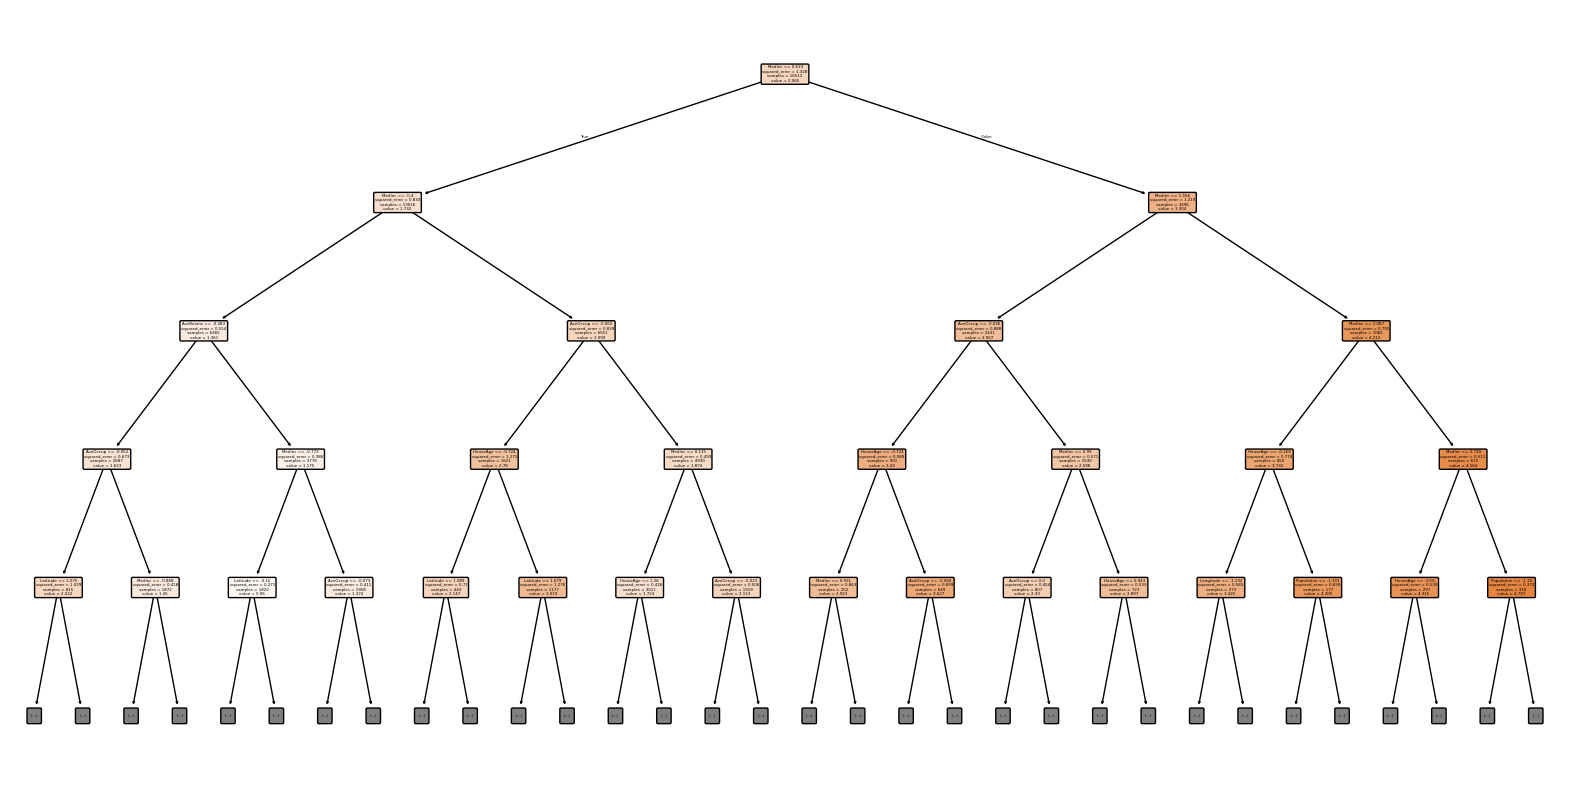

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_reg,
    feature_names=data.feature_names,
    filled=True,
    rounded=True,
    max_depth=4
)
plt.show()

In [27]:
joblib.dump(dt_reg, 'decision_tree_regressor_model.pkl')
print("Decision Tree Regressor model saved as 'decision_tree_regressor_model.pkl'.")

Decision Tree Regressor model saved as 'decision_tree_regressor_model.pkl'.


In [28]:
loaded_dt_reg = joblib.load('decision_tree_regressor_model.pkl')

In [33]:
def predict_house_value_dt(features_list):
    scaled = scaler.transform(features_list)
    pred = loaded_dt_reg.predict(scaled)[0]
    return float(pred)

In [34]:
test = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=data.feature_names)

In [35]:
test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3,29,6.5,1.0,400,3.5,34.2,-118.4


In [36]:
print(predict_house_value_dt(test))

4.602128356164382


## Random Forest Regressor

In [37]:
rf_reg = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    oob_score=True,
    min_samples_split=3,
    min_samples_leaf=1,
    bootstrap=True,
    max_features="sqrt",
    random_state=42
)

In [38]:
rf_reg.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samp

In [39]:
print("OOB Score (R square) (100 estimators) (None as max_depth):", rf_reg.oob_score_)

OOB Score (R square) (100 estimators) (None as max_depth): 0.7761327379057548


In [40]:
rf_pred = rf_reg.predict(x_test_scaled)

In [41]:
print("Random Forest Regression Performance")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R squared score:", r2_score(y_test, rf_pred))

Random Forest Regression Performance
MAE: 0.3855901775058547
MSE: 0.3055979312161644
RMSE: 0.5528091272909343
R squared score: 0.7731311078776074


In [42]:
imp = rf_reg.feature_importances_
for nam, score in zip(data.feature_names, imp):
    print(f"{name}: {score:.4f}")

Longitude: 0.4106
Longitude: 0.0483
Longitude: 0.1253
Longitude: 0.0278
Longitude: 0.0177
Longitude: 0.1176
Longitude: 0.1297
Longitude: 0.1230


In [43]:
joblib.dump(rf_reg, "random_forest_regressor.pkl")
print("Random forest Regressor saved")

Random forest Regressor saved


In [44]:
loaded_rf_reg = joblib.load("random_forest_regressor.pkl")

In [55]:
def predict_house_price_value_rf(features_list):
    scaled = scaler.transform(features_list)
    pred = loaded_rf_reg.predict(scaled)[0]
    return float(pred)

In [56]:
test_rf = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=data.feature_names)

In [57]:
print(predict_house_price_value_rf(test_rf))

3.9589713422454067
